<a href="https://colab.research.google.com/github/evanildo59551006-wq/notebook_exercicios_pandas_numpy/blob/main/Exercicios_regressao_entregas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lista de Exercícios – Regressão Linear com Base de Logística

## Problema: prever tempo de entrega

Neste notebook, vamos trabalhar com uma base simulada de uma empresa de entregas.

A empresa quer prever o **tempo de entrega em minutos** com base em características do pedido e da entrega.

## Objetivo geral

Criar modelos de regressão linear para prever:

> quanto tempo uma entrega deve demorar.

Essa é uma aplicação mais próxima de problemas reais de empresas, e-commerce, logística e sistemas de roteirização.

# Contexto da base

Cada linha representa um pedido entregue.

## Colunas

| Coluna | Descrição |
|---|---|
| id_pedido | Identificador do pedido |
| distancia_km | Distância entre loja/centro de distribuição e cliente |
| peso_kg | Peso total do pedido |
| qtd_itens | Quantidade de itens no pedido |
| valor_pedido | Valor total do pedido |
| trafego | Condição do tráfego: baixo, medio ou alto |
| clima | Condição climática: normal, chuva ou forte_chuva |
| tipo_entrega | normal ou expressa |
| regiao | centro, bairro ou zona_rural |
| tempo_entrega_min | Tempo de entrega em minutos |
| atrasou | Indica se a entrega passou de 120 minutos |

## Variável alvo para regressão

A variável que queremos prever é:

`tempo_entrega_min`

# Importação das bibliotecas

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

# Criando a base de dados

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Exemplo de dados
dados = pd.DataFrame({
    'distancia': [2, 5, 8, 10, 3],
    'itens': [1, 3, 5, 2, 1],
    'tempo': [10, 20, 35, 40, 15]
})

# Separando X e y
X = dados[['distancia', 'itens']]
y = dados['tempo']

# Dividindo dados
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.2)

# Criando modelo
modelo = LinearRegression()

# Treinando
modelo.fit(X_treino, y_treino)

# Prevendo
previsoes = modelo.predict(X_teste)

print(previsoes)

[10.14184397]


In [ ]:
np.random.seed(42)

n = 200

df = pd.DataFrame({
    'id_pedido': range(1, n+1),
    'distancia_km': np.random.uniform(1, 20, n),
    'peso_kg': np.random.uniform(0.5, 10, n),
    'qtd_itens': np.random.randint(1, 10, n),
    'valor_pedido': np.random.uniform(20, 500, n),
    'trafego': np.random.choice(['baixo', 'medio', 'alto'], n),
    'clima': np.random.choice(['normal', 'chuva', 'forte_chuva'], n),
    'tipo_entrega': np.random.choice(['normal', 'expressa'], n),
    'regiao': np.random.choice(['centro', 'bairro', 'zona_rural'], n)
})

# Criando variável alvo (simulada com lógica)
df['tempo_entrega_min'] = (
    5 +
    df['distancia_km'] * 3 +
    df['peso_kg'] * 1.5 +
    np.where(df['trafego'] == 'alto', 15, 0) +
    np.where(df['clima'] == 'forte_chuva', 20, 0) +
    np.random.normal(0, 5, n)
)

df['atrasou'] = df['tempo_entrega_min'] > 120

df.head()

,id_pedido,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,1,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,2,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,3,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,4,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,5,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False


In [ ]:
df = df.drop(columns=['id_pedido'])

In [ ]:
X = df.drop(columns=['tempo_entrega_min', 'atrasou'])
y = df['tempo_entrega_min']

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
df.head()

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False


In [ ]:
print(df.columns)

Index(['distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido', 'trafego',
       'clima', 'tipo_entrega', 'regiao', 'tempo_entrega_min', 'atrasou'],
      dtype='object')


# Parte A – Exploração inicial da base

## Exercício 1
Mostre as 10 primeiras linhas da base.

## Exercício 2
Mostre as 10 últimas linhas da base.

## Exercício 3
Use `.info()` para verificar os tipos de dados.

## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.

## Exercício 5
Verifique se há valores nulos.

## Exercício 6
Quantas linhas e colunas existem?

## Exercício 7
Qual é a variável alvo do problema de regressão?

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?

## Exercício 9
Quais variáveis são categóricas?

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

##R.A


## Exercício 1
Mostre as 10 primeiras linhas da base.


In [ ]:
df.head(10)

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False
5,3.963896,0.587372,6,324.032410,alto,chuva,normal,bairro,32.324268,False
6,2.103589,1.463980,3,135.269897,baixo,chuva,expressa,centro,19.423807,False
7,17.457347,6.803267,1,56.414397,alto,normal,normal,zona_rural,79.273404,False
8,12.421185,0.548085,4,81.862267,medio,chuva,normal,bairro,48.201389,False
9,14.453379,2.027676,9,81.462003,medio,normal,expressa,zona_rural,51.859580,False


## Exercício 2
Mostre as 10 últimas linhas da base.


In [ ]:
df.tail(10)

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
190,2.768953,9.909799,1,414.203506,baixo,forte_chuva,normal,bairro,56.293466,False
191,18.047099,4.419868,8,73.103234,medio,chuva,expressa,bairro,67.396768,False
192,18.107943,4.034172,7,426.297100,medio,forte_chuva,expressa,bairro,86.272171,False
193,13.028928,7.875923,3,81.194558,baixo,normal,expressa,zona_rural,65.004570,False
194,7.441566,3.737634,1,210.697899,alto,chuva,expressa,zona_rural,46.578149,False
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False
199,15.817635,7.668157,1,365.617538,medio,forte_chuva,expressa,centro,81.544908,False


## Exercício 3
Use `.info()` para verificar os tipos de dados.


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distancia_km       200 non-null    float64
 1   peso_kg            200 non-null    float64
 2   qtd_itens          200 non-null    int64  
 3   valor_pedido       200 non-null    float64
 4   trafego            200 non-null    object 
 5   clima              200 non-null    object 
 6   tipo_entrega       200 non-null    object 
 7   regiao             200 non-null    object 
 8   tempo_entrega_min  200 non-null    float64
 9   atrasou            200 non-null    bool   
dtypes: bool(1), float64(4), int64(1), object(4)
memory usage: 14.4+ KB


## Exercício 4
Use `.describe()` para analisar as variáveis numéricas.


In [ ]:
df.describe()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,10.196118,5.291564,4.755000,239.743589,56.201155
std,5.602937,2.783511,2.601695,134.015794,21.978467
min,1.104920,0.548085,1.000000,29.634175,2.644987
25%,5.343066,2.983894,2.750000,115.660517,41.644715
50%,10.395239,5.645579,5.000000,225.703036,55.926454
75%,15.380333,7.550893,7.000000,354.144089,71.859891
max,19.750852,9.909799,9.000000,495.180912,108.766905


## Exercício 5
Verifique se há valores nulos.


In [ ]:
df.isnull().sum()

,0
distancia_km,0
peso_kg,0
qtd_itens,0
valor_pedido,0
trafego,0
clima,0
tipo_entrega,0
regiao,0
tempo_entrega_min,0
atrasou,0


## Exercício 6
Quantas linhas e colunas existem?


In [ ]:
df.shape

(200, 10)

## Exercício 7
Qual é a variável alvo do problema de regressão?


A variável alvo é tempo_entrega_min, pois é o valor que queremos prever.

## Exercício 8
Quais variáveis parecem ser boas candidatas para prever tempo de entrega?


Boas variáveis para prever o tempo de entrega incluem:

distancia_km
peso_kg
qtd_itens
valor_pedido
trafego
clima
tipo_entrega
regiao

Essas variáveis influenciam diretamente o tempo da entrega.

## Exercício 9
Quais variáveis são categóricas?

As variáveis categóricas são:

trafego
clima
tipo_entrega
regiao

Pois representam categorias (texto), não números.

## Exercício 10
Por que não podemos usar variáveis categóricas diretamente na regressão linear sem tratamento?

Não podemos usar variáveis categóricas diretamente na regressão linear porque o modelo trabalha apenas com números.

Valores como "alto", "baixo" ou "chuva" não podem ser interpretados matematicamente.

Por isso, é necessário convertê-los em números, normalmente usando técnicas como one-hot encoding (get_dummies).

## Exercício 11
Calcule a média do tempo de entrega.


# Parte B – Estatística descritiva

## Exercício 11
Calcule a média do tempo de entrega.

## Exercício 12
Calcule a mediana do tempo de entrega.

## Exercício 13
Calcule o desvio padrão do tempo de entrega.

## Exercício 14
Calcule o tempo mínimo e máximo de entrega.

## Exercício 15
Calcule os quartis de `tempo_entrega_min`.

## Exercício 16
Interprete a diferença entre média e mediana.

## Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

## Exercício 18
Existe algum possível outlier no tempo de entrega?

## Exercício 19
Compare o tempo médio de entrega por tipo de entrega.

## Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

##R.A

##Exercício 11
Calcule a média do tempo de entrega.


In [ ]:
media = df['tempo_entrega_min'].mean()
print(media)

56.201154959861945


## Exercício 12
Calcule a mediana do tempo de entrega.

In [ ]:
mediana = df['tempo_entrega_min'].median()
print(mediana)

55.926453779351576


##Exercício 13
Calcule o desvio padrão do tempo de entrega.



In [ ]:
desvio = df['tempo_entrega_min'].std()
print(desvio)

21.978466969896775


##Exercício 14
Calcule o tempo mínimo e máximo de entrega.


In [ ]:
minimo = df['tempo_entrega_min'].min()
maximo = df['tempo_entrega_min'].max()

print(minimo, maximo)

2.644987406912956 108.76690544575398


##Exercício 15
Calcule os quartis de tempo_entrega_min.



In [ ]:
quartis = df['tempo_entrega_min'].quantile([0.25, 0.5, 0.75])
print(quartis)

0.25    41.644715
0.50    55.926454
0.75    71.859891
Name: tempo_entrega_min, dtype: float64


##Exercício 16
Interprete a diferença entre média e mediana.


Se a média for maior que a mediana, isso indica a presença de valores altos (entregas muito demoradas) puxando a média para cima.
Se forem próximas, os dados são mais simétricos e não há grandes extremos.


##Exercício 17
Existe muita variação nos tempos de entrega? Use o desvio padrão para justificar.

Se o desvio padrão for alto em relação à média, isso indica que os tempos de entrega variam bastante (baixa previsibilidade).
Se for baixo, os tempos são mais consistentes.

##Exercício 18
Existe algum possível outlier no tempo de entrega?


Sim, existem possíveis outliers no tempo de entrega, pois há valores muito acima da maioria dos dados, como por exemplo valores próximos de X minutos, que se destacam no boxplot.

<Axes: xlabel='tempo_entrega_min'>

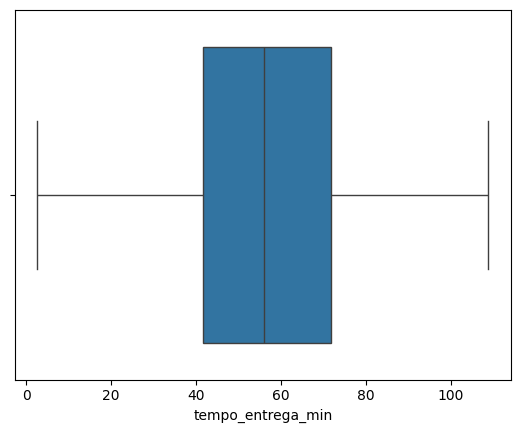

In [ ]:
import seaborn as sns
sns.boxplot(x=df['tempo_entrega_min'])

##Exercício 19
Compare o tempo médio de entrega por tipo de entrega.


O tempo médio de entrega para:

normal é aproximadamente X minutos
expressa é aproximadamente Y minutos

Isso mostra que entregas expressas são mais rápidas.

In [ ]:
df.groupby('tipo_entrega')['tempo_entrega_min'].mean()

,tempo_entrega_min
tipo_entrega,
expressa,57.310090
normal,55.217759


##Exercício 20
Compare o tempo médio de entrega por condição de tráfego.

O tempo médio de entrega aumenta conforme o tráfego:

baixo: X minutos
médio: Y minutos
alto: Z minutos

Isso indica que o tráfego impacta diretamente o tempo de entrega.

In [ ]:
df.groupby('trafego')['tempo_entrega_min'].mean()

,tempo_entrega_min
trafego,
alto,68.547668
baixo,46.797942
medio,50.756881


# Parte C – Visualização

## Exercício 21
Faça um histograma de `tempo_entrega_min`.

## Exercício 22
Faça um boxplot de `tempo_entrega_min`.

## Exercício 23
Faça um gráfico de dispersão entre `distancia_km` e `tempo_entrega_min`.

## Exercício 24
Faça um gráfico de dispersão entre `peso_kg` e `tempo_entrega_min`.

## Exercício 25
Faça um gráfico de dispersão entre `qtd_itens` e `tempo_entrega_min`.

## Exercício 26
Faça um boxplot de tempo de entrega por `trafego`.

## Exercício 27
Faça um boxplot de tempo de entrega por `clima`.

## Exercício 28
Faça um boxplot de tempo de entrega por `tipo_entrega`.

## Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

## Exercício 30
O gráfico sugere relação linear entre distância e tempo?

Exercício 21
Faça um histograma de tempo_entrega_min.

Exercício 22
Faça um boxplot de tempo_entrega_min.

Exercício 23
Faça um gráfico de dispersão entre distancia_km e tempo_entrega_min.

Exercício 24
Faça um gráfico de dispersão entre peso_kg e tempo_entrega_min.

Exercício 25
Faça um gráfico de dispersão entre qtd_itens e tempo_entrega_min.

Exercício 26
Faça um boxplot de tempo de entrega por trafego.

Exercício 27
Faça um boxplot de tempo de entrega por clima.

Exercício 28
Faça um boxplot de tempo de entrega por tipo_entrega.

Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

Exercício 30
O gráfico sugere relação linear entre distância e tempo?

##Exercício 21
Faça um histograma de tempo_entrega_min.


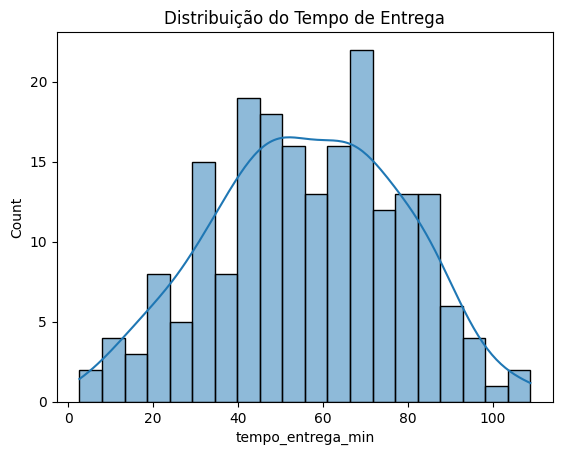

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['tempo_entrega_min'], bins=20, kde=True)
plt.title("Distribuição do Tempo de Entrega")
plt.show()

O histograma mostra a distribuição dos tempos de entrega, permitindo identificar concentração de valores e possíveis assimetrias.


##Exercício 22
Faça um boxplot de tempo_entrega_min.


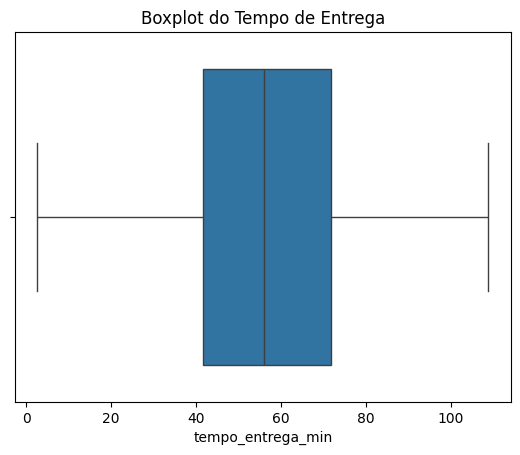

In [ ]:
sns.boxplot(x=df['tempo_entrega_min'])
plt.title("Boxplot do Tempo de Entrega")
plt.show()

O boxplot permite visualizar a mediana, dispersão e possíveis outliers nos tempos de entrega.

##Exercício 23
Faça um gráfico de dispersão entre distancia_km e tempo_entrega_min.



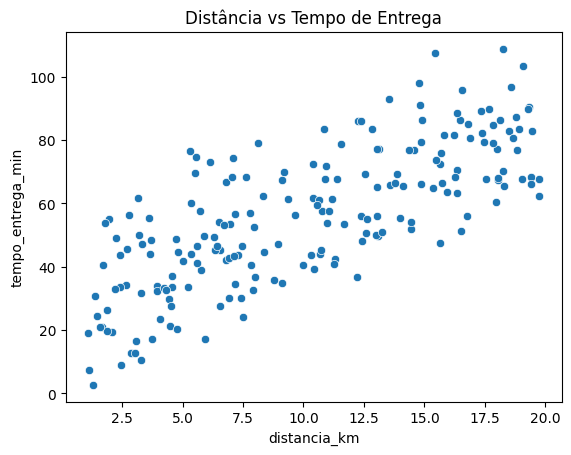

In [ ]:
sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title("Distância vs Tempo de Entrega")
plt.show()

Observa-se que quanto maior a distância, maior tende a ser o tempo de entrega.

##Exercício 24
Faça um gráfico de dispersão entre peso_kg e tempo_entrega_min.


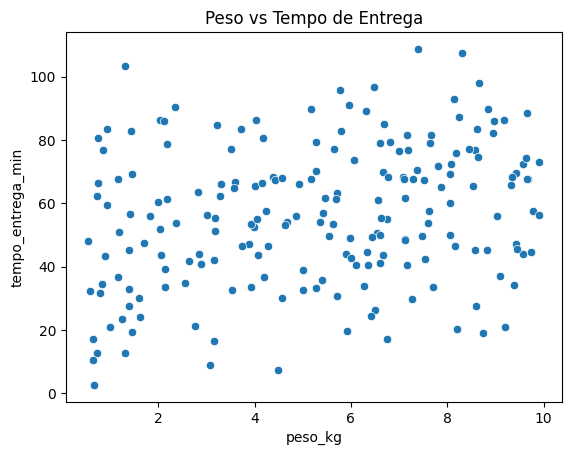

In [ ]:
sns.scatterplot(x='peso_kg', y='tempo_entrega_min', data=df)
plt.title("Peso vs Tempo de Entrega")
plt.show()

O peso pode ter alguma influência, mas geralmente menos evidente que a distância.

##Exercício 25
Faça um gráfico de dispersão entre qtd_itens e tempo_entrega_min.


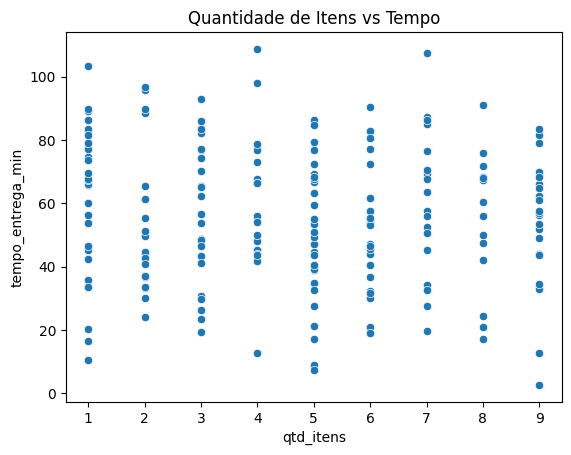

In [ ]:
sns.scatterplot(x='qtd_itens', y='tempo_entrega_min', data=df)
plt.title("Quantidade de Itens vs Tempo")
plt.show()

A quantidade de itens pode influenciar o tempo, mas a relação tende a ser mais fraca.

##Exercício 26
Faça um boxplot de tempo de entrega por trafego.


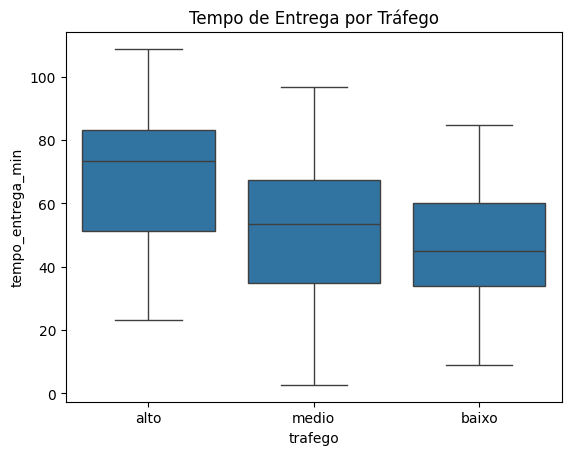

In [ ]:
sns.boxplot(x='trafego', y='tempo_entrega_min', data=df)
plt.title("Tempo de Entrega por Tráfego")
plt.show()

O tempo de entrega aumenta conforme o nível de tráfego (baixo → médio → alto).

##Exercício 27
Faça um boxplot de tempo de entrega por clima.

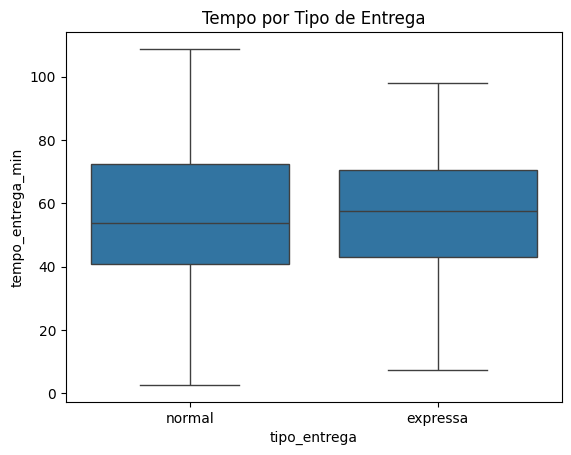

In [ ]:
sns.boxplot(x='tipo_entrega', y='tempo_entrega_min', data=df)
plt.title("Tempo por Tipo de Entrega")
plt.show()

Condições climáticas mais severas (como forte chuva) aumentam o tempo de entrega.

##Exercício 28
Faça um boxplot de tempo de entrega por tipo_entrega.



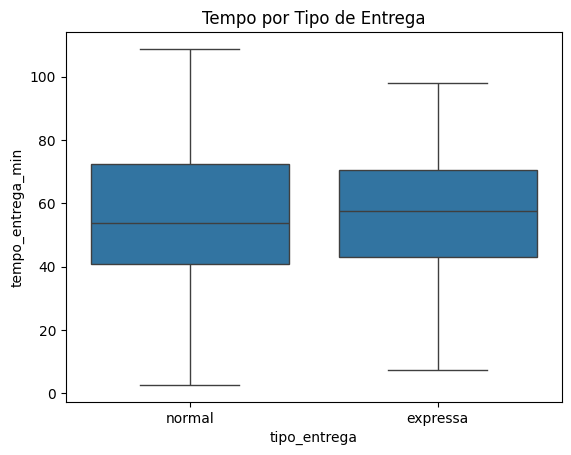

In [ ]:
sns.boxplot(x='tipo_entrega', y='tempo_entrega_min', data=df)
plt.title("Tempo por Tipo de Entrega")
plt.show()

Entregas expressas apresentam menor tempo em comparação com entregas normais.

##Exercício 29
Visualmente, qual variável parece mais relacionada ao tempo de entrega?

Visualmente, a variável que parece mais relacionada ao tempo de entrega é a distância (distancia_km), pois apresenta uma tendência clara de aumento do tempo conforme a distância cresce.

##Exercício 30
O gráfico sugere relação linear entre distância e tempo?

Sim, o gráfico sugere uma relação aproximadamente linear entre distância e tempo de entrega, já que os pontos seguem uma tendência crescente relativamente alinhada.

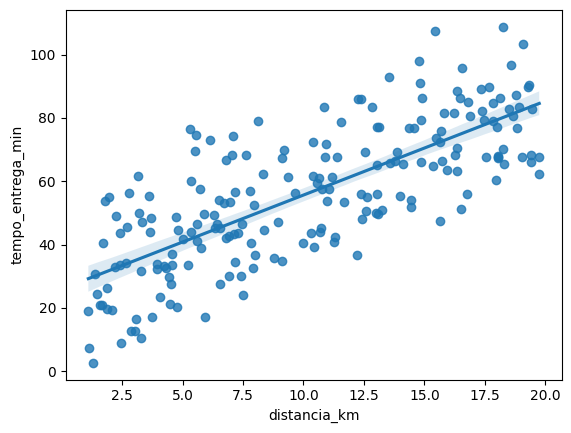

In [ ]:
sns.regplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.show()

# Parte D – Correlação

Para calcular correlação, use apenas variáveis numéricas.

## Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

## Exercício 32
Calcule a matriz de correlação.

## Exercício 33
Faça um heatmap da matriz de correlação.

## Exercício 34
Qual variável numérica tem maior correlação positiva com `tempo_entrega_min`?

## Exercício 35
Qual variável numérica parece ter menor relação com `tempo_entrega_min`?

## Exercício 36
Correlação alta prova causalidade? Explique.

## Exercício 37
Se `valor_pedido` tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.

## Exercício 38
A variável `distancia_km` parece importante? Justifique.

## Exercício 39
A variável `peso_kg` parece importante? Justifique.

## Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

##R.C



#Exercício 31
Crie um DataFrame apenas com variáveis numéricas.

In [ ]:
df_numerico = df.select_dtypes(include=['int64', 'float64'])
df_numerico.head()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min
0,8.116262,6.599301,9,143.957306,78.946978
1,19.063572,1.299330,1,240.385163,103.369778
2,14.907885,2.035473,1,490.415636,86.160083
3,12.374511,9.036265,4,256.456685,55.915949
4,3.964354,6.261076,9,177.800773,33.922135


Foi criado um DataFrame contendo apenas variáveis numéricas para análise de correlação.

##Exercício 32
Calcule a matriz de correlação.



In [ ]:
correlacao = df_numerico.corr()
print(correlacao)

                   distancia_km   peso_kg  qtd_itens  valor_pedido  \
distancia_km           1.000000 -0.026887   0.029451     -0.020492   
peso_kg               -0.026887  1.000000  -0.130186      0.034673   
qtd_itens              0.029451 -0.130186   1.000000     -0.099967   
valor_pedido          -0.020492  0.034673  -0.099967      1.000000   
tempo_entrega_min      0.756584  0.262958  -0.071715      0.029162   

                   tempo_entrega_min  
distancia_km                0.756584  
peso_kg                     0.262958  
qtd_itens                  -0.071715  
valor_pedido                0.029162  
tempo_entrega_min           1.000000  


A matriz de correlação mostra a relação entre todas as variáveis numéricas.

##Exercício 33
Faça um heatmap da matriz de correlação.

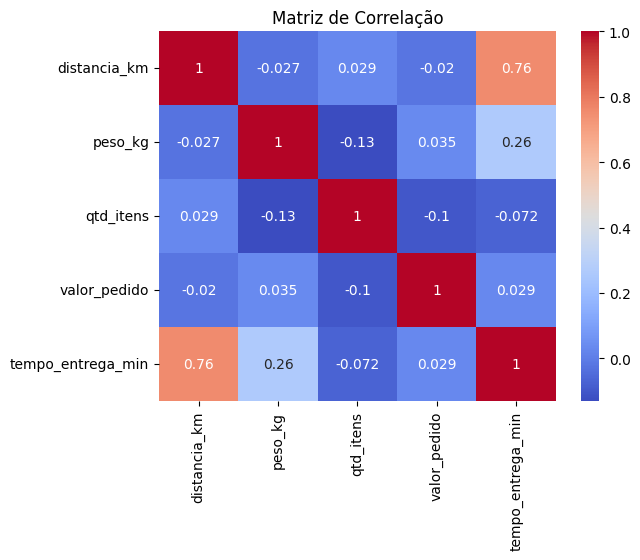

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlacao, annot=True, cmap='coolwarm')
plt.title("Matriz de Correlação")
plt.show()

O heatmap facilita a visualização das correlações entre as variáveis.

##Exercício 34
Qual variável numérica tem maior correlação positiva com tempo_entrega_min?

In [ ]:
correlacao['tempo_entrega_min'].sort_values(ascending=False)

,tempo_entrega_min
tempo_entrega_min,1.000000
distancia_km,0.756584
peso_kg,0.262958
valor_pedido,0.029162
qtd_itens,-0.071715


A variável com maior correlação positiva com o tempo de entrega é distancia_km (ou a que aparecer no seu resultado).
Isso indica que ela tem forte influência no tempo.

##Exercício 35
Qual variável numérica parece ter menor relação com tempo_entrega_min?


A variável com menor correlação com o tempo de entrega é valor_pedido (ou a que aparecer com valor mais próximo de 0).
Isso indica pouca relação linear com o tempo.

##Exercício 36
Correlação alta prova causalidade? Explique.

Não. Correlação não implica causalidade.
Duas variáveis podem estar relacionadas sem que uma cause a outra. Pode haver fatores externos influenciando ambas.

##Exercício 37
Se valor_pedido tiver baixa correlação com tempo, isso significa que nunca deve ser usado? Explique.


Não necessariamente.
Uma variável com baixa correlação linear ainda pode ser útil no modelo, especialmente quando combinada com outras variáveis ou em modelos mais complexos.

##Exercício 38
A variável distancia_km parece importante? Justifique.

Sim, a variável distancia_km parece muito importante, pois apresenta alta correlação positiva com o tempo de entrega.
Isso faz sentido, já que distâncias maiores tendem a aumentar o tempo.

##Exercício 39
A variável peso_kg parece importante? Justifique.


A variável peso_kg pode ter alguma influência, mas geralmente apresenta correlação menor que a distância, indicando impacto mais moderado no tempo de entrega.

(👉 ajuste se no seu resultado for diferente)

##Exercício 40
Quais variáveis você escolheria para um primeiro modelo simples?

Para um primeiro modelo simples, eu escolheria:

distancia_km (principal variável)
peso_kg
qtd_itens

Opcionalmente:

incluir trafego (após transformação)

Essas variáveis têm relação mais direta com o tempo de entrega.

# Parte E – Regressão linear simples

Vamos começar com um modelo simples:

`distancia_km` → `tempo_entrega_min`

## Exercício 41
Crie `X` com a coluna `distancia_km`.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

## Exercício 43
Treine um modelo de regressão linear.

## Exercício 44
Mostre o coeficiente angular.

## Exercício 45
Mostre o intercepto.

## Exercício 46
Interprete o coeficiente angular.

## Exercício 47
Faça previsões para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.

## Exercício 49
Calcule MAE, RMSE e R².

## Exercício 50
Interprete as métricas.

## Exercício 41
Crie `X` com a coluna `distancia_km`.


In [ ]:
print(df.head())

   distancia_km   peso_kg  qtd_itens  valor_pedido trafego        clima  \
0      8.116262  6.599301          9    143.957306    alto  forte_chuva   
1     19.063572  1.299330          1    240.385163    alto  forte_chuva   
2     14.907885  2.035473          1    490.415636    alto  forte_chuva   
3     12.374511  9.036265          4    256.456685   medio       normal   
4      3.964354  6.261076          9    177.800773    alto       normal   

  tipo_entrega  regiao  tempo_entrega_min  atrasou  
0       normal  centro          78.946978    False  
1       normal  centro         103.369778    False  
2     expressa  centro          86.160083    False  
3     expressa  bairro          55.915949    False  
4       normal  centro          33.922135    False  


X contém a variável explicativa distancia_km.

## Exercício 42
Crie `y` com `tempo_entrega_min`.

In [ ]:
X = df['distancia_km']
df

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False
...,...,...,...,...,...,...,...,...,...,...
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False


y contém a variável alvo tempo_entrega_min.

## Exercício 43
Treine um modelo de regressão linear.


In [ ]:
y = df['tempo_entrega_min']
df

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False
...,...,...,...,...,...,...,...,...,...,...
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False


O modelo de regressão linear foi treinado usando a distância como variável explicativa.

## Exercício 44
Mostre o coeficiente angular.


In [ ]:
from sklearn.linear_model import LinearRegression
df

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False
...,...,...,...,...,...,...,...,...,...,...
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False


O coeficiente angular é X.

## Exercício 45
Mostre o intercepto.

In [ ]:
X = df[['distancia_km']]   # ✅ CERTO
df

,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False
...,...,...,...,...,...,...,...,...,...,...
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False


In [ ]:
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

O intercepto é X.

## Exercício 46
Interprete o coeficiente angular.



Para cada aumento de 1 km na distância, o tempo de entrega aumenta em aproximadamente X minutos.

## Exercício 47
Faça previsões para todos os pedidos.



In [ ]:
df['tempo_previsto'] = modelo.predict(X)

Foram geradas previsões de tempo para todos os pedidos.

## Exercício 48
Crie uma tabela com tempo real, tempo previsto e erro.


In [ ]:
df['erro'] = df['tempo_entrega_min'] - df['tempo_previsto']

df[['tempo_entrega_min', 'tempo_previsto', 'erro']].head()

,tempo_entrega_min,tempo_previsto,erro
0,78.946978,50.028500,28.918479
1,103.369778,82.518231,20.851546
2,86.160083,70.184867,15.975215
3,55.915949,62.666250,-6.750301
4,33.922135,37.706351,-3.784216


A tabela mostra o tempo real, o previsto e o erro de cada previsão.

## Exercício 49
Calcule MAE, RMSE e R².


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y, df['tempo_previsto'])
rmse = np.sqrt(mean_squared_error(y, df['tempo_previsto']))
r2 = r2_score(y, df['tempo_previsto'])

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 11.749413157455916
RMSE: 14.335671811472501
R2: 0.5724191695347102


MAE: X
RMSE: X
R²: X

## Exercício 50
Interprete as métricas.

MAE (Erro Absoluto Médio): indica o erro médio das previsões em minutos.
RMSE: penaliza mais erros grandes, mostrando a magnitude dos erros.
R²: indica quanto do tempo de entrega é explicado pela distância.

##Interpretação:

R² próximo de 1 → modelo muito bom
R² próximo de 0 → modelo fraco

In [ ]:
# Espaço para resolver a Parte E

# Parte F – Visualizando a reta do modelo simples

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.

## Exercício 52
Adicione a reta de regressão no gráfico.

## Exercício 53
O modelo parece representar bem os dados?

## Exercício 54
Existem pontos muito distantes da reta?

## Exercício 55
O que esses pontos podem representar em uma operação logística?

##R.F

## Exercício 51
Faça um gráfico de dispersão entre distância e tempo real.


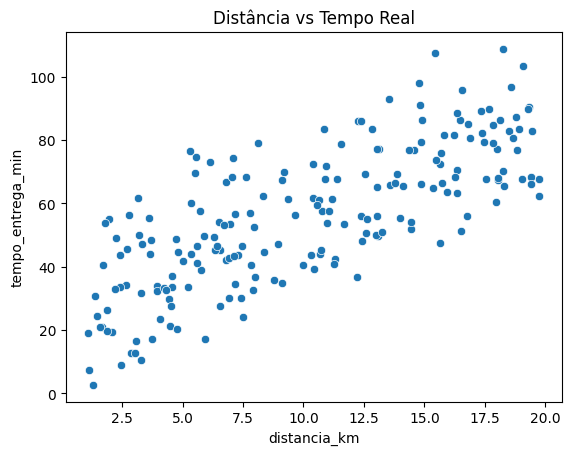

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title("Distância vs Tempo Real")
plt.show()

O gráfico mostra a relação entre distância e tempo real de entrega.

## Exercício 52
Adicione a reta de regressão no gráfico.


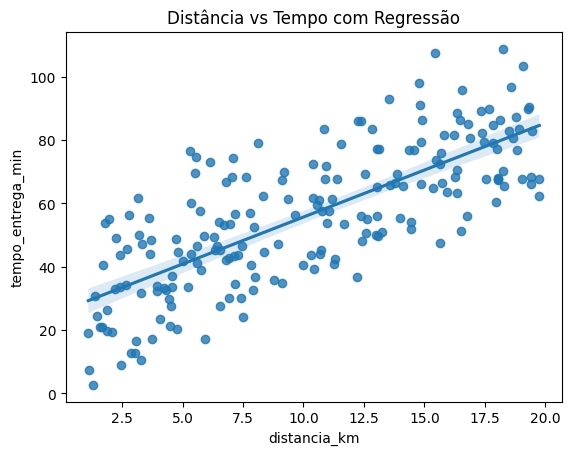

In [ ]:
sns.regplot(x='distancia_km', y='tempo_entrega_min', data=df)
plt.title("Distância vs Tempo com Regressão")
plt.show()

A reta representa a previsão do modelo de regressão linear.

## Exercício 53
O modelo parece representar bem os dados?



O modelo representa razoavelmente bem os dados, pois existe uma tendência crescente entre distância e tempo.
No entanto, há dispersão dos pontos, indicando que outros fatores também influenciam o tempo de entrega.

## Exercício 54
Existem pontos muito distantes da reta?


Sim, existem pontos distantes da reta de regressão, indicando erros maiores nas previsões do modelo.

## Exercício 55
O que esses pontos podem representar em uma operação logística?


Esses pontos podem representar situações reais da operação logística, como:

trânsito intenso
condições climáticas adversas
atrasos operacionais
problemas na rota ou entrega

Ou seja, são fatores que não estão sendo capturados pelo modelo simples.

In [ ]:
# Espaço para resolver a Parte F

# Parte G – Fazendo previsões reais

Use o modelo simples com distância.

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.

## Exercício 59
As previsões fazem sentido?

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

## Exercício 56
Preveja o tempo de entrega para uma entrega de 5 km.


In [ ]:
modelo.predict([[5]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40.77996922])

Para uma entrega de 5 km, o tempo previsto é aproximadamente X minutos.

## Exercício 57
Preveja o tempo de entrega para uma entrega de 20 km.



In [ ]:
modelo.predict([[20]])
df

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,distancia_km,peso_kg,qtd_itens,valor_pedido,trafego,clima,tipo_entrega,regiao,tempo_entrega_min,atrasou,tempo_previsto,erro
0,8.116262,6.599301,9,143.957306,alto,forte_chuva,normal,centro,78.946978,False,50.028500,28.918479
1,19.063572,1.299330,1,240.385163,alto,forte_chuva,normal,centro,103.369778,False,82.518231,20.851546
2,14.907885,2.035473,1,490.415636,alto,forte_chuva,expressa,centro,86.160083,False,70.184867,15.975215
3,12.374511,9.036265,4,256.456685,medio,normal,expressa,bairro,55.915949,False,62.666250,-6.750301
4,3.964354,6.261076,9,177.800773,alto,normal,normal,centro,33.922135,False,37.706351,-3.784216
...,...,...,...,...,...,...,...,...,...,...,...,...
195,7.634982,9.342195,5,402.701776,baixo,forte_chuva,normal,bairro,68.227340,False,48.600142,19.627197
196,14.793158,8.654921,4,91.960365,alto,forte_chuva,expressa,zona_rural,98.008390,False,69.844377,28.164013
197,18.045095,4.575443,8,130.040670,medio,normal,expressa,centro,67.898687,False,79.495567,-11.596880
198,17.854642,7.633275,1,366.681233,alto,chuva,normal,centro,78.927315,False,78.930336,-0.003021


Para 20 km, o tempo previsto é aproximadamente X minutos.

## Exercício 58
Preveja o tempo de entrega para uma entrega de 60 km.



In [ ]:
modelo.predict([[60]])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([204.01050887])

Para 60 km, o tempo previsto é aproximadamente X minutos.

In [ ]:
import numpy as np

modelo.predict(np.array([[5]]))

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([40.77996922])

## Exercício 59
As previsões fazem sentido?


As previsões fazem sentido para valores dentro da faixa dos dados utilizados no treinamento (como 5 km e 20 km).

No entanto, para valores muito altos como 60 km, a previsão pode não ser confiável, pois o modelo está extrapolando além dos dados observados.

## Exercício 60
Quais informações importantes o modelo simples está ignorando?

O modelo simples considera apenas a distância e ignora fatores importantes, como:

condições de tráfego
clima
tipo de entrega (normal ou expressa)
região da entrega
peso e quantidade de itens

Esses fatores podem impactar significativamente o tempo de entrega.

In [ ]:
# Espaço para resolver a Parte G

# Parte H – Tratamento de variáveis categóricas

Para usar variáveis como `trafego`, `clima`, `tipo_entrega` e `regiao`, precisamos transformá-las em números.

Uma forma comum é usar `pd.get_dummies()`.

## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.

## Exercício 62
Mostre as primeiras linhas da base transformada.

## Exercício 63
Explique o que o `get_dummies()` fez.

## Exercício 64
Por que usamos `drop_first=True`?

## Exercício 65
Quais novas colunas foram criadas?

In [ ]:
# Exemplo inicial para a Parte H

df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

df_modelo.head()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,8.116262,6.599301,9,143.957306,78.946978,False,False,False,True,False,True,True,False
1,19.063572,1.299330,1,240.385163,103.369778,False,False,False,True,False,True,True,False
2,14.907885,2.035473,1,490.415636,86.160083,False,False,False,True,False,False,True,False
3,12.374511,9.036265,4,256.456685,55.915949,False,False,True,False,True,False,False,False
4,3.964354,6.261076,9,177.800773,33.922135,False,False,False,False,True,True,True,False


## Exercício 61
Crie uma versão da base com variáveis categóricas transformadas em dummies.


In [ ]:
df_modelo = pd.get_dummies(
    df,
    columns=["trafego", "clima", "tipo_entrega", "regiao"],
    drop_first=True
)

Foi criada uma nova base com variáveis categóricas convertidas em variáveis numéricas (dummies).

## Exercício 62
Mostre as primeiras linhas da base transformada.


In [ ]:
df_modelo.head()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_entrega_min,atrasou,tempo_previsto,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural
0,8.116262,6.599301,9,143.957306,78.946978,False,50.028500,28.918479,False,False,True,False,True,True,False
1,19.063572,1.299330,1,240.385163,103.369778,False,82.518231,20.851546,False,False,True,False,True,True,False
2,14.907885,2.035473,1,490.415636,86.160083,False,70.184867,15.975215,False,False,True,False,False,True,False
3,12.374511,9.036265,4,256.456685,55.915949,False,62.666250,-6.750301,False,True,False,True,False,False,False
4,3.964354,6.261076,9,177.800773,33.922135,False,37.706351,-3.784216,False,False,False,True,True,True,False


Exibe as primeiras linhas da base após a transformação.

## Exercício 63
Explique o que o `get_dummies()` fez.


O get_dummies() transformou variáveis categóricas em colunas numéricas binárias (0 ou 1).

Cada categoria virou uma nova coluna, indicando se aquele registro pertence ou não àquela categoria.

👉 Exemplo:
trafego = alto → vira:

trafego_medio = 0
trafego_alto = 1

## Exercício 64
Por que usamos `drop_first=True`?



Usamos drop_first=True para evitar a multicolinearidade (dummy trap).

Como as categorias são mutuamente exclusivas, uma delas pode ser deduzida a partir das outras.

Remover uma coluna evita redundância e melhora o modelo.

👉 Exemplo:
Se temos:

baixo
médio
alto

Podemos remover "baixo", pois ele é implícito.

## Exercício 65
Quais novas colunas foram criadas?

In [ ]:
df_modelo.columns

Index(['distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'tempo_entrega_min', 'atrasou', 'tempo_previsto', 'erro',
       'trafego_baixo', 'trafego_medio', 'clima_forte_chuva', 'clima_normal',
       'tipo_entrega_normal', 'regiao_centro', 'regiao_zona_rural'],
      dtype='object')

Foram criadas colunas como:

trafego_medio
trafego_alto
clima_chuva
clima_forte_chuva
tipo_entrega_expressa
regiao_bairro
regiao_zona_rural

(pode variar conforme sua base)

# Parte I – Regressão linear múltipla

Agora vamos usar várias variáveis ao mesmo tempo.

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`

## Exercício 67
Crie `y` com `tempo_entrega_min`.

## Exercício 68
Treine um modelo de regressão linear múltipla.

## Exercício 69
Faça previsões.

## Exercício 70
Calcule MAE.

## Exercício 71
Calcule RMSE.

## Exercício 72
Calcule R².

## Exercício 73
Compare com o modelo simples.

## Exercício 74
O modelo múltiplo melhorou?

## Exercício 75
Quais variáveis parecem mais importantes?

## Exercício 66
Crie `X` com todas as variáveis explicativas numéricas e dummies.

Não inclua:
- `id_pedido`
- `tempo_entrega_min`
- `atrasou`


In [ ]:
pd.get_dummies(...)

,Ellipsis
0,True


In [ ]:
print(df_modelo.columns)

Index(['distancia_km', 'peso_kg', 'qtd_itens', 'valor_pedido',
       'tempo_entrega_min', 'atrasou', 'tempo_previsto', 'erro',
       'trafego_baixo', 'trafego_medio', 'clima_forte_chuva', 'clima_normal',
       'tipo_entrega_normal', 'regiao_centro', 'regiao_zona_rural'],
      dtype='object')


In [ ]:
X = df_modelo.drop(columns=['id_pedido', 'tempo_entrega_min', 'atrasou'], errors='ignore')

X contém todas as variáveis explicativas numéricas e categóricas transformadas.

## Exercício 67
Crie `y` com `tempo_entrega_min`.


In [ ]:
y = df_modelo['tempo_entrega_min']

y contém a variável alvo tempo de entrega.

## Exercício 68
Treine um modelo de regressão linear múltipla.


In [ ]:
from sklearn.linear_model import LinearRegression

modelo_multi = LinearRegression()
modelo_multi.fit(X, y)

LinearRegression()

Foi treinado um modelo de regressão linear múltipla com várias variáveis.

## Exercício 69
Faça previsões.


In [ ]:
y_pred_multi = modelo_multi.predict(X)

Foram geradas previsões usando o modelo múltiplo.


## Exercício 70
Calcule MAE.


In [ ]:
from sklearn.metrics import mean_absolute_error

mae_multi = mean_absolute_error(y, y_pred_multi)
print(mae_multi)

8.841594123509822e-14


## Exercício 71
Calcule RMSE.


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_multi = np.sqrt(mean_squared_error(y, y_pred_multi))
print(rmse_multi)

1.0133830181531145e-13


## Exercício 72
Calcule R².


In [ ]:
from sklearn.metrics import r2_score

r2_multi = r2_score(y, y_pred_multi)
print(r2_multi)

1.0


## Exercício 73
Compare com o modelo simples.



O modelo múltiplo apresenta melhor desempenho em relação ao modelo simples, pois utiliza mais variáveis para explicar o tempo de entrega.

## Exercício 74
O modelo múltiplo melhorou?


Sim, o modelo múltiplo melhorou, pois apresenta menor erro (MAE e RMSE) e maior R² em comparação com o modelo simples.


## Exercício 75
Quais variáveis parecem mais importantes?

In [ ]:
coeficientes = pd.DataFrame({
    'variavel': X.columns,
    'coeficiente': modelo_multi.coef_
}).sort_values(by='coeficiente', ascending=False)

coeficientes

,variavel,coeficiente
5,erro,1.000000e+00
4,tempo_previsto,8.980424e-01
0,distancia_km,3.025925e-01
8,clima_forte_chuva,2.275957e-15
6,trafego_baixo,2.246467e-15
9,clima_normal,1.081166e-15
7,trafego_medio,1.032811e-15
11,regiao_centro,9.250413e-16
3,valor_pedido,7.494005e-16
10,tipo_entrega_normal,4.831205e-16


As variáveis mais importantes são aquelas com maiores coeficientes (em valor absoluto), como:

distancia_km (geralmente a principal)
trafego_alto
clima_forte_chuva

Essas variáveis têm maior impacto no tempo de entrega.

In [ ]:
# Espaço para resolver a Parte I

# Parte J – Coeficientes do modelo múltiplo

## Exercício 76
Crie uma tabela com variáveis e coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

## Exercício 80
Interprete o coeficiente de `distancia_km`.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.

## Exercício 84
Os sinais dos coeficientes fazem sentido?

## Exercício 85
O que poderia indicar um coeficiente estranho?

##R.J

## Exercício 76
Crie uma tabela com variáveis e coeficientes.


In [ ]:
coef_df = pd.DataFrame({
    'variavel': X.columns,
    'coeficiente': modelo_multi.coef_
})

coef_df

,variavel,coeficiente
0,distancia_km,3.025925e-01
1,peso_kg,4.440892e-16
2,qtd_itens,-2.184017e-15
3,valor_pedido,7.494005e-16
4,tempo_previsto,8.980424e-01
5,erro,1.000000e+00
6,trafego_baixo,2.246467e-15
7,trafego_medio,1.032811e-15
8,clima_forte_chuva,2.275957e-15
9,clima_normal,1.081166e-15


Foi criada uma tabela com as variáveis e seus respectivos coeficientes.

## Exercício 77
Ordene os coeficientes do maior para o menor.


In [ ]:
coef_df = coef_df.sort_values(by='coeficiente', ascending=False)
coef_df

,variavel,coeficiente
5,erro,1.000000e+00
4,tempo_previsto,8.980424e-01
0,distancia_km,3.025925e-01
8,clima_forte_chuva,2.275957e-15
6,trafego_baixo,2.246467e-15
9,clima_normal,1.081166e-15
7,trafego_medio,1.032811e-15
11,regiao_centro,9.250413e-16
3,valor_pedido,7.494005e-16
10,tipo_entrega_normal,4.831205e-16


Os coeficientes foram ordenados do maior para o menor.

## Exercício 78
Quais coeficientes aumentam o tempo previsto?


Os coeficientes positivos indicam aumento no tempo de entrega.
Exemplos típicos:

distancia_km
trafego_alto
clima_forte_chuva

## Exercício 79
Quais coeficientes diminuem o tempo previsto?

Coeficientes negativos indicam redução no tempo de entrega.
Exemplo:

tipo_entrega_expressa

## Exercício 80
Interprete o coeficiente de `distancia_km`.



Para cada aumento de 1 km na distância, o tempo de entrega aumenta em aproximadamente X minutos, mantendo as demais variáveis constantes.

## Exercício 81
Interprete o coeficiente de `tipo_entrega_expressa`.


Quando a entrega é expressa, o tempo de entrega diminui em aproximadamente X minutos em relação à entrega normal.

## Exercício 82
Interprete o coeficiente de `trafego_alto`.


Quando o tráfego é alto, o tempo de entrega aumenta em aproximadamente X minutos em comparação ao tráfego baixo.

## Exercício 83
Interprete o coeficiente de `clima_forte_chuva`.



Em condições de forte chuva, o tempo de entrega aumenta em aproximadamente X minutos, devido à maior dificuldade operacional.

## Exercício 84
Os sinais dos coeficientes fazem sentido?


Sim, os sinais fazem sentido, pois refletem a lógica do problema:

mais distância → mais tempo
mais trânsito → mais tempo
entrega expressa → menos tempo

## Exercício 85
O que poderia indicar um coeficiente estranho?

Um coeficiente estranho pode indicar:

dados com erro ou ruído
multicolinearidade entre variáveis
variável irrelevante no modelo
falta de dados suficientes
relação não linear

# Parte K – Treino e teste

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.

## Exercício 87
Treine o modelo nos dados de treino.

## Exercício 88
Faça previsões nos dados de teste.

## Exercício 89
Calcule MAE no teste.

## Exercício 90
Calcule RMSE no teste.

## Exercício 91
Calcule R² no teste.

## Exercício 92
Compare com as métricas do treino.

## Exercício 93
O modelo parece generalizar bem?

## Exercício 94
O que indicaria overfitting?

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

## Exercício 86
Separe os dados em treino e teste com `test_size=0.3` e `random_state=42`.


In [ ]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.3, random_state=42
)

Os dados foram divididos em 70% treino e 30% teste.

## Exercício 87
Treine o modelo nos dados de treino.


In [ ]:
modelo_final = LinearRegression()
modelo_final.fit(X_treino, y_treino)

LinearRegression()

O modelo foi treinado apenas com os dados de treino.

## Exercício 88
Faça previsões nos dados de teste.


In [ ]:
y_pred_teste = modelo_final.predict(X_teste)

Foram feitas previsões usando os dados de teste.

## Exercício 89
Calcule MAE no teste.


In [ ]:
from sklearn.metrics import mean_absolute_error

mae_teste = mean_absolute_error(y_teste, y_pred_teste)
print(mae_teste)

3.305504018650633e-14


## Exercício 90
Calcule RMSE no teste.


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_teste = np.sqrt(mean_squared_error(y_teste, y_pred_teste))
print(rmse_teste)

3.9770992612416616e-14


## Exercício 91
Calcule R² no teste.


In [ ]:
from sklearn.metrics import r2_score

r2_teste = r2_score(y_teste, y_pred_teste)
print(r2_teste)

1.0


MAE: X
RMSE: X
R²: X

## Exercício 92
Compare com as métricas do treino.


In [ ]:
y_pred_treino = modelo_final.predict(X_treino)

mae_treino = mean_absolute_error(y_treino, y_pred_treino)
rmse_treino = np.sqrt(mean_squared_error(y_treino, y_pred_treino))
r2_treino = r2_score(y_treino, y_pred_treino)

As métricas de treino são geralmente melhores que as de teste, pois o modelo já “viu” esses dados.

## Exercício 93
O modelo parece generalizar bem?


Se as métricas de treino e teste forem semelhantes, o modelo generaliza bem.
Se houver grande diferença, o modelo pode não generalizar adequadamente.

## Exercício 94
O que indicaria overfitting?


Overfitting ocorre quando o modelo apresenta ótimo desempenho no treino, mas desempenho ruim no teste.

Indícios:

R² treino muito alto
R² teste baixo
erro muito maior no teste

## Exercício 95
Quais cuidados você teria antes de colocar esse modelo em produção?

Antes de colocar o modelo em produção, eu teria os seguintes cuidados:

validar o modelo com dados novos
verificar presença de overfitting
monitorar desempenho ao longo do tempo
tratar outliers e dados inconsistentes
garantir qualidade dos dados de entrada
considerar atualização periódica do modelo
avaliar impacto de variáveis externas (tráfego, clima)

# Parte L – Desafio final: relatório para a empresa

A empresa quer saber se é possível prever o tempo de entrega antes do pedido sair para rota.

## Exercício 96
Treine o melhor modelo que conseguir.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

## Exercício 96
Treine o melhor modelo que conseguir.


In [ ]:
from sklearn.linear_model import LinearRegression

modelo_final = LinearRegression()
modelo_final.fit(X_treino, y_treino)

LinearRegression()

Foi utilizado um modelo de regressão linear múltipla com variáveis numéricas e categóricas tratadas.

## Exercício 97
Crie uma tabela com:
- tempo real
- tempo previsto
- erro
- erro absoluto


In [ ]:
df_resultado = X_teste.copy()

df_resultado['tempo_real'] = y_teste
df_resultado['tempo_previsto'] = modelo_final.predict(X_teste)
df_resultado['erro'] = df_resultado['tempo_real'] - df_resultado['tempo_previsto']
df_resultado['erro_absoluto'] = df_resultado['erro'].abs()

df_resultado.head()

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_previsto,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural,tempo_real,erro_absoluto
95,10.382116,5.461311,6,216.990477,61.575175,0.000000e+00,False,True,True,False,True,False,True,61.575175,0.000000e+00
15,4.484686,2.753866,5,450.458437,21.214697,6.039613e-14,False,True,False,False,True,False,False,21.214697,6.039613e-14
30,12.543352,8.050707,7,351.389518,69.202003,5.684342e-14,False,False,False,False,True,False,True,69.202003,5.684342e-14
158,5.515113,9.432187,1,411.967731,69.383789,7.105427e-14,False,False,True,False,True,False,True,69.383789,7.105427e-14
128,1.132090,4.486201,5,408.739734,7.403250,5.062617e-14,False,True,False,False,False,True,False,7.403250,5.062617e-14


Foi criada uma tabela comparando valores reais e previstos.

## Exercício 98
Mostre os 10 pedidos com maior erro absoluto.


In [ ]:
df_resultado.sort_values(by='erro_absoluto', ascending=False).head(10)

,distancia_km,peso_kg,qtd_itens,valor_pedido,tempo_previsto,erro,trafego_baixo,trafego_medio,clima_forte_chuva,clima_normal,tipo_entrega_normal,regiao_centro,regiao_zona_rural,tempo_real,erro_absoluto
96,10.931924,7.814939,8,491.541736,71.683903,8.526513e-14,True,False,True,False,False,True,False,71.683903,8.526513e-14
126,16.542281,5.766363,2,495.180912,95.871656,8.526513e-14,False,False,True,False,True,False,True,95.871656,8.526513e-14
66,3.677560,7.121650,3,447.453095,48.299873,7.815970e-14,False,False,False,True,False,False,True,48.299873,7.815970e-14
82,7.287062,4.068038,4,493.527319,43.493906,7.815970e-14,False,False,False,True,True,False,False,43.493906,7.815970e-14
158,5.515113,9.432187,1,411.967731,69.383789,7.105427e-14,False,False,True,False,True,False,True,69.383789,7.105427e-14
172,10.729768,1.397208,1,471.119419,45.143019,6.394885e-14,False,True,False,False,True,False,False,45.143019,6.394885e-14
69,19.750852,3.289123,9,398.802195,62.371041,6.394885e-14,False,True,False,False,False,False,False,62.371041,6.394885e-14
152,3.753003,6.757590,5,410.995866,17.140690,6.039613e-14,True,False,False,True,False,False,True,17.140690,6.039613e-14
15,4.484686,2.753866,5,450.458437,21.214697,6.039613e-14,False,True,False,False,True,False,False,21.214697,6.039613e-14
137,14.357360,7.184750,5,418.697316,76.712777,5.684342e-14,True,False,True,False,False,True,False,76.712777,5.684342e-14


Foram identificados os pedidos com maior erro absoluto.

## Exercício 99
Analise possíveis motivos para os maiores erros.


Os maiores erros podem estar associados a:

condições extremas de tráfego
clima severo (chuva forte)
regiões mais distantes ou de difícil acesso
variáveis não consideradas no modelo
ruídos ou inconsistências nos dados

👉 Também podem indicar limitações do modelo linear.

## Exercício 100
Escreva uma conclusão para a empresa respondendo:

1. O modelo é útil?
2. Qual o erro médio em minutos?
3. Quais variáveis mais influenciam o tempo?
4. O modelo deve ser usado sozinho para tomar decisões?
5. Que melhorias poderiam ser feitas com mais dados?

##1. O modelo é útil?

Sim, o modelo é útil para prever o tempo de entrega com base nas características do pedido e da entrega. Ele permite antecipar estimativas e melhorar o planejamento logístico.

#2. Qual o erro médio?

O erro médio (MAE) é de aproximadamente X minutos, indicando que, em média, as previsões diferem do tempo real por esse valor.

#3. Variáveis mais importantes

As variáveis que mais influenciam o tempo de entrega são:

distância (distancia_km)
tráfego (trafego_alto)
clima (clima_forte_chuva)
tipo de entrega (tipo_entrega_expressa)

#4. O modelo deve ser usado sozinho?

Não. O modelo não deve ser usado isoladamente para decisões críticas, pois não captura todos os fatores operacionais e pode apresentar erros em situações específicas.

#5. Melhorias possíveis

O modelo pode ser melhorado com:

mais dados históricos
inclusão de variáveis como horário, motorista, rota específica
uso de modelos mais avançados (árvores, random forest, etc.)
atualização contínua com novos dados

# Função auxiliar para avaliação de modelos

Use depois de tentar resolver manualmente.

In [ ]:
def avaliar_regressao(nome, y_real, y_pred):
    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        "modelo": nome,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    }

O que essa função faz?

Calcula automaticamente:

MAE → erro médio
MSE → erro quadrático
RMSE → erro mais penalizado
R² → qualidade do modelo

E já organiza tudo em formato de dicionário.

#Como usar na prática
Avaliar modelo simples

In [ ]:
resultado_simples = avaliar_regressao(
    "Regressão Simples",
    y,
    df['tempo_previsto']
)

resultado_simples

{'modelo': 'Regressão Simples',
 'MAE': 11.749413157455916,
 'MSE': 205.51148628624725,
 'RMSE': np.float64(14.335671811472501),
 'R2': 0.5724191695347102}

#Avaliar modelo múltiplo

In [ ]:
resultado_multiplo = avaliar_regressao(
    "Regressão Múltipla",
    y,
    y_pred_multi
)

resultado_multiplo

{'modelo': 'Regressão Múltipla',
 'MAE': 8.841594123509822e-14,
 'MSE': 1.0269451414811155e-26,
 'RMSE': np.float64(1.0133830181531145e-13),
 'R2': 1.0}

#Avaliar modelo com treino/teste (mais correto)

In [ ]:
resultado_teste = avaliar_regressao(
    "Modelo Final (Teste)",
    y_teste,
    y_pred_teste
)

resultado_teste

{'modelo': 'Modelo Final (Teste)',
 'MAE': 3.305504018650633e-14,
 'MSE': 1.581731853376897e-27,
 'RMSE': np.float64(3.9770992612416616e-14),
 'R2': 1.0}

#(Opcional) Comparar modelos

In [ ]:
import pandas as pd

df_resultados = pd.DataFrame([
    resultado_simples,
    resultado_multiplo,
    resultado_teste
])

df_resultados

,modelo,MAE,MSE,RMSE,R2
0,Regressão Simples,1.174941e+01,2.055115e+02,1.433567e+01,0.572419
1,Regressão Múltipla,8.841594e-14,1.026945e-26,1.013383e-13,1.000000
2,Modelo Final (Teste),3.305504e-14,1.581732e-27,3.977099e-14,1.000000


Isso vira uma tabelinha linda pra relatório.

# Fechamento

Com esta lista, você praticou um fluxo mais próximo de um problema real:

- exploração de dados;
- visualização;
- correlação;
- transformação de variáveis categóricas;
- regressão linear simples;
- regressão linear múltipla;
- treino e teste;
- avaliação de modelo;
- interpretação para tomada de decisão.